In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [11]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
print(train_df.shape)
print(test_df.shape)

(891, 12)
(418, 11)


In [15]:
# handling missing values
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

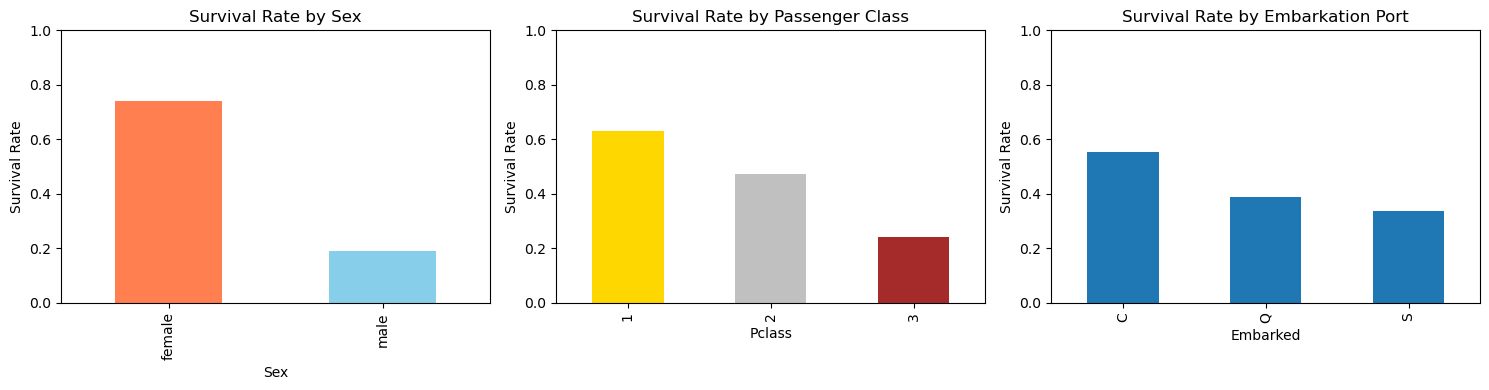

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# By Sex
train_df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0], color=['coral', 'skyblue'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)

# By Class
train_df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['gold', 'silver', 'brown'])
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)

# By Embarked
train_df.groupby('Embarked')['Survived'].mean().plot(kind='bar', ax=axes[2])
axes[2].set_title('Survival Rate by Embarkation Port')
axes[2].set_ylabel('Survival Rate')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [19]:
def extract_title(name):
    title = name.split(',')[1].split('.')[0].strip()
    # Group rare titles
    if title in ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']:
        return 'Rare'
    elif title in ['Mlle', 'Ms']:
        return 'Miss'
    elif title == 'Mme':
        return 'Mrs'
    return title

In [20]:
def feature_engineering(df):
  df = df.copy()
  df['Title'] = df['Name'].apply(extract_title)
  df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
  df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
  df['Age'] = df['Age'].fillna(df['Age'].median())
  df['Fare'] = df['Fare'].fillna(df['Fare'].median())
  df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
  return df

In [21]:
# Apply feature engineering
train_fe = feature_engineering(train_df)
test_fe = feature_engineering(test_df)

In [30]:
train_fe[['Name', 'Title', 'FamilySize', 'IsAlone']].head()

,Name,Title,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0
2,"Heikkinen, Miss. Laina",Miss,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0
4,"Allen, Mr. William Henry",Mr,1,1


In [27]:
feature_columns = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']

# Combine train and test df
combined = pd.concat([train_fe[feature_columns], test_fe[feature_columns]], axis=0)

# Convert categorical variables to numeric (one-hot encoding)
combined_encoded = pd.get_dummies(combined, columns=['Sex', 'Embarked', 'Title'], drop_first=True,dtype = int)

In [28]:
combined_encoded.head()

,Pclass,Age,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
0,3,22.0,7.2500,2,0,1,0,1,0,1,0,0,0
1,1,38.0,71.2833,2,0,0,0,0,0,0,1,0,0
2,3,26.0,7.9250,1,1,0,0,1,1,0,0,0,0
3,1,35.0,53.1000,2,0,0,0,1,0,0,1,0,0
4,3,35.0,8.0500,1,1,1,0,1,0,1,0,0,0


In [29]:
X_train = combined_encoded[:len(train_fe)]
X_test = combined_encoded[len(train_fe):]
y_train = train_fe['Survived']

In [31]:
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"\nFeatures used: {list(X_train.columns)}")

Training features shape: (891, 13)
Test features shape: (418, 13)

Features used: ['Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Title_the Countess']


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [33]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

In [34]:
# Cross-validation to evaluate model
lr_cv_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='accuracy')

print("Logistic Regression Cross-Validation Scores:")
print(f"  Individual folds: {lr_cv_scores}")
print(f"  Mean CV Accuracy: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")

Logistic Regression Cross-Validation Scores:
  Individual folds: [0.81564246 0.82022472 0.80898876 0.80337079 0.84831461]
  Mean CV Accuracy: 0.8193 (+/- 0.0156)


In [36]:
# Train on full training set
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [37]:
lr_predictions = lr_model.predict(X_test)

print(f"Predictions made: {len(lr_predictions)}")
print(f"Predicted survival rate: {lr_predictions.mean():.2%}")

Predictions made: 418
Predicted survival rate: 39.23%


In [38]:
lr_submission = pd.DataFrame({
    'PassengerId': test_fe['PassengerId'],
    'Survived': lr_predictions
})
lr_submission.to_csv('submission_logistic_regression.csv', index=False)

In [39]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

In [40]:
# Cross-validation
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='accuracy')
print("Decision Tree Cross-Validation Scores:")
print(f"  Individual folds: {dt_cv_scores}")
print(f"  Mean CV Accuracy: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std():.4f})")

Decision Tree Cross-Validation Scores:
  Individual folds: [0.77094972 0.78651685 0.83707865 0.78089888 0.83146067]
  Mean CV Accuracy: 0.8014 (+/- 0.0274)


In [42]:
# Train on full training set
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [43]:
dt_predictions = dt_model.predict(X_test)

print(f"Predictions made: {len(dt_predictions)}")
print(f"Predicted survival rate: {dt_predictions.mean():.2%}")

Predictions made: 418
Predicted survival rate: 37.80%


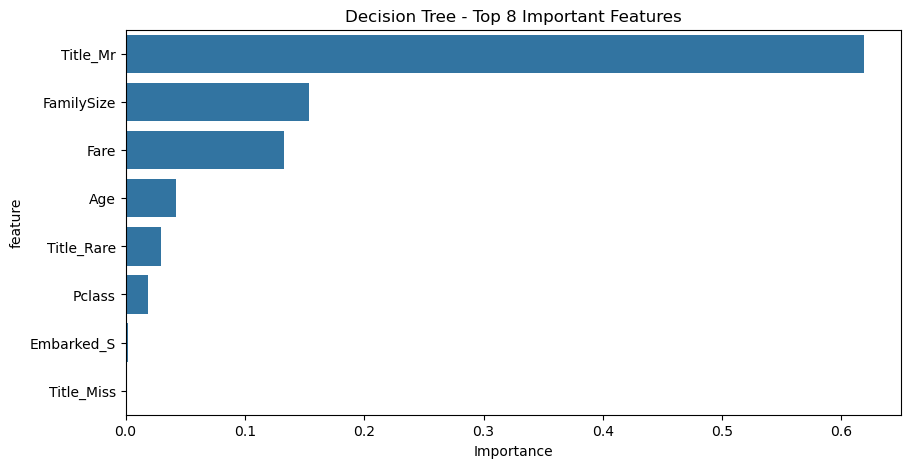

In [44]:
# Feature importance from Decision Tree
dt_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=dt_importance.head(8), x='importance', y='feature')
plt.title('Decision Tree - Top 8 Important Features')
plt.xlabel('Importance')
plt.show()

In [52]:
# Create submission file
dt_submission = pd.DataFrame({
    'PassengerId': test_fe['PassengerId'],
    'Survived': dt_predictions
})
dt_submission.to_csv('submission_decision_tree.csv', index=False)

In [46]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

In [47]:
# Cross-validation
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print("Random Forest Cross-Validation Scores:")
print(f"  Individual folds: {rf_cv_scores}")
print(f"  Mean CV Accuracy: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

Random Forest Cross-Validation Scores:
  Individual folds: [0.82122905 0.81460674 0.84269663 0.80337079 0.86516854]
  Mean CV Accuracy: 0.8294 (+/- 0.0220)


In [48]:
# Train on full training set
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, min_samples_leaf=4, min_samples_split=10,
                       random_state=42)

In [49]:
rf_predictions = rf_model.predict(X_test)

print(f"Predictions made: {len(rf_predictions)}")
print(f"Predicted survival rate: {rf_predictions.mean():.2%}")

Predictions made: 418
Predicted survival rate: 36.84%


In [51]:
# Create submission file
rf_submission = pd.DataFrame({
    'PassengerId': test_fe['PassengerId'],
    'Survived': rf_predictions
})
rf_submission.to_csv('submission_random_forest.csv', index=False)